[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%208%20Modern%20Decision%20Trees/08-DecisionTrees-ModernView.ipynb)

# Lecture 8: From Questions to Learnable Decisions

A tree asks a sequence of questions. What do those questions tell us, when do more questions stop helping, and what changes when an input can contribute to several answers?

We will return to the same [Home Credit applications](https://www.kaggle.com/competitions/home-credit-default-risk/data). The dataset's target records **payment difficulties**, not a loan-approval decision. These historical classroom examples are not a lending policy. The umbrella example and impurity calculations stay on the whiteboard; here we make the mechanisms visible.

In [27]:
# Setup: the Kaggle data are not bundled or downloaded automatically.
import os
from pathlib import Path
if 'google.colab' in __import__('sys').modules:
    from google.colab import files
    if not Path('data/application_train.csv').exists():
        print('Upload application_train.csv from the linked competition (requires Kaggle access).')
        uploaded = files.upload()
        if 'application_train.csv' in uploaded:
            Path('data').mkdir(exist_ok=True)
            Path('application_train.csv').replace('data/application_train.csv')

In [28]:
import copy
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display, clear_output, HTML
from IPython.utils.capture import capture_output
import ipywidgets as widgets
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
                             log_loss, confusion_matrix, precision_recall_curve)
from sklearn.calibration import calibration_curve
import torch
from torch import nn

torch.set_num_threads(2)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'axes.titleweight': 'bold', 'axes.titlepad': 12,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'grid.alpha': .18, 'figure.dpi': 110, 'legend.frameon': False})
COLORS = {'train': '#3A86FF', 'val': '#E76F51', 'soft': '#2A9D8F',
          'ink': '#263238', 'muted': '#8D99AE', 'positive': '#8338EC'}
RISK_CMAP = 'YlOrRd'

def table(rows, formats=None):
    display(pd.DataFrame(rows).style.hide(axis='index').format(formats or {}, precision=3))

def explore(fn, **controls):
    """One static default for GitHub; clicking replaces it with one live figure."""
    with capture_output() as initial:
        fn(**{name: control.value for name, control in controls.items()})
    # Display IDs let callbacks update this cell in Notebook 7 and JupyterLab.
    # Bare display/clear_output calls in a button callback have no cell target.
    handles = [display(output, display_id=True) for output in initial.outputs]
    if not handles:
        handles = [display(HTML(''), display_id=True)]
    button = widgets.Button(description='Explore this figure', icon='sliders',
                            layout=widgets.Layout(width='190px'))
    def activate(_):
        live = widgets.interactive(fn, **controls)
        handles[0].update(live)
        for handle in handles[1:]:
            handle.update(HTML(''))
        button.layout.display = 'none'
    button.on_click(activate)
    display(button)


## 1. Follow One Application

We keep training, validation, and test applications separate. Validation is for comparing settings; the test set stays closed until the last section. To keep CPU training practical, every main model gets the **same 60,000 training applications** with the original class proportions.

We use ten numerical features, including the three external scores. Their underlying construction is not provided by the dataset. Missing-value medians and scaling are learned from training data only. An exceptional employment-duration code is treated as missing, not as zero years of employment.

In [29]:
data_path = Path('data/application_train.csv')
if not data_path.exists():
    raise FileNotFoundError('Place application_train.csv from Home Credit in this lecture\'s data/ folder.')
columns = ['TARGET', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE',
           'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
raw = pd.read_csv(data_path, usecols=columns)
X = raw.rename(columns={'AMT_CREDIT': 'Loan amount', 'AMT_INCOME_TOTAL': 'Income',
    'AMT_GOODS_PRICE': 'Goods price', 'EXT_SOURCE_1': 'External score 1',
    'EXT_SOURCE_2': 'External score 2', 'EXT_SOURCE_3': 'External score 3'}).drop(
    columns=['TARGET', 'DAYS_BIRTH', 'DAYS_EMPLOYED'])
X['Age'] = -raw.DAYS_BIRTH / 365.25
X['Years employed'] = -raw.DAYS_EMPLOYED.where(raw.DAYS_EMPLOYED <= 0) / 365.25
X['Loan / income'] = X['Loan amount'] / X.Income.where(X.Income > 0)
X['Goods / loan'] = X['Goods price'] / X['Loan amount'].where(X['Loan amount'] > 0)
y = raw.TARGET.to_numpy()
pool_ids, test_ids = train_test_split(np.arange(len(y)), test_size=.2, stratify=y, random_state=42)
train_pool, val_ids = train_test_split(pool_ids, test_size=.25, stratify=y[pool_ids], random_state=42)
train_ids, _ = train_test_split(train_pool, train_size=60000, stratify=y[train_pool], random_state=42)
assert not (set(train_ids) & set(val_ids) or set(train_ids) & set(test_ids) or set(val_ids) & set(test_ids))
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X.iloc[train_ids]), columns=X.columns)
X_val = pd.DataFrame(imputer.transform(X.iloc[val_ids]), columns=X.columns)
y_train, y_val = y[train_ids], y[val_ids]
scaler = StandardScaler().fit(X_train)
train_scaled = scaler.transform(X_train).astype('float32')
val_scaled = scaler.transform(X_val).astype('float32')
print(f'{len(train_ids):,} training · {len(val_ids):,} validation · {len(test_ids):,} untouched test applications')
print(f'Training positive rate: {y_train.mean():.1%} · {X_train.shape[1]} numerical features')
shallow = DecisionTreeClassifier(max_depth=2, min_samples_leaf=40, random_state=42).fit(X_train, y_train)

60,000 training · 61,502 validation · 61,503 untouched test applications
Training positive rate: 8.1% · 10 numerical features


In [38]:
def application_path(application=44, threshold=.5):
    row = X_val.iloc[[application]]
    t = shallow.tree_
    path = set(shallow.decision_path(row).indices)
    leaf = shallow.apply(row)[0]
    risks = t.value[:, 0, 1] / t.value[:, 0, :].sum(axis=1)
    fig, ax = plt.subplots(figsize=(12, 5.8))
    artists = plot_tree(shallow, feature_names=X.columns, node_ids=True,
                        filled=False, rounded=True, ax=ax, fontsize=11)
    # Branch labels are annotations too; identify node boxes explicitly.
    for artist in artists:
        match = re.search(r'node #(\d+)', artist.get_text())
        if match is None:
            continue
        node = int(match.group(1))
        rule = (f'{X.columns[t.feature[node]]} ≤ {t.threshold[node]:.2f}'
                if t.children_left[node] != -1 else f'Leaf {node}')
        label = f'{rule}\nn = {t.n_node_samples[node]:,} · risk = {risks[node]:.1%}'
        if t.children_left[node] == -1:
            label += '\nFlag' if risks[node] >= threshold else '\nDo not flag'
        artist.set_text(label)
        patch = artist.get_bbox_patch()
        patch.set_facecolor('#E5F3EF' if node in path else '#F5F6F8')
        patch.set_edgecolor(COLORS['soft'] if node in path else '#CFD5DA')
        patch.set_linewidth(2.4 if node in path else 1)
    ax.set_title(f'Application {application}: follow the questions', fontsize=16)
    detail = ' · '.join(f'{X.columns[k]} = {row.iloc[0, k]:.2f}' for k in sorted(set(t.feature[list(path)]) - {-2}))
    fig.text(.5, .075, detail, ha='center', color=COLORS['ink'], fontsize=11)
    fig.text(.5, .025, f'Estimated risk {risks[leaf]:.1%} · flagging threshold {threshold:.0%} '
             f'· recorded outcome: {"payment difficulties" if y_val[application] else "no payment difficulties"}',
             ha='center', fontsize=11)
    fig.subplots_adjust(bottom=.15, top=.90)
    plt.show()

explore(application_path,
        application=widgets.IntSlider(value=44, min=0, max=99, description='Application', continuous_update=False),
        threshold=widgets.FloatSlider(value=.5, min=.02, max=.5, step=.01, description='Threshold', continuous_update=False))

interactive(children=(IntSlider(value=44, continuous_update=False, description='Application', max=99), FloatSl…

Button(description='Explore this figure', icon='sliders', layout=Layout(width='190px'), style=ButtonStyle())

Look at the leaf risks before changing the threshold. Do the leaves make identical predictions, or only identical **class decisions**? Try a lower threshold: the decisions can change without relearning a single split.

On the whiteboard, the 5/5 umbrella group has Gini impurity 0.50. Splitting it into 4/1 and 1/4 groups gives weighted impurity 0.32, a reduction of 0.18. The tree greedily chooses a useful split at each node; it does not search all possible complete trees.

## 2. What Changes When Mistakes Count Differently?

Threshold adjustment changes a decision rule after fitting. Resampling and class weighting instead change training. Here the three trees share depth 3 and the same minimum leaf size. Only the training treatment changes; validation keeps its original positive rate. Weighted leaf scores should not automatically be read as calibrated population risks.

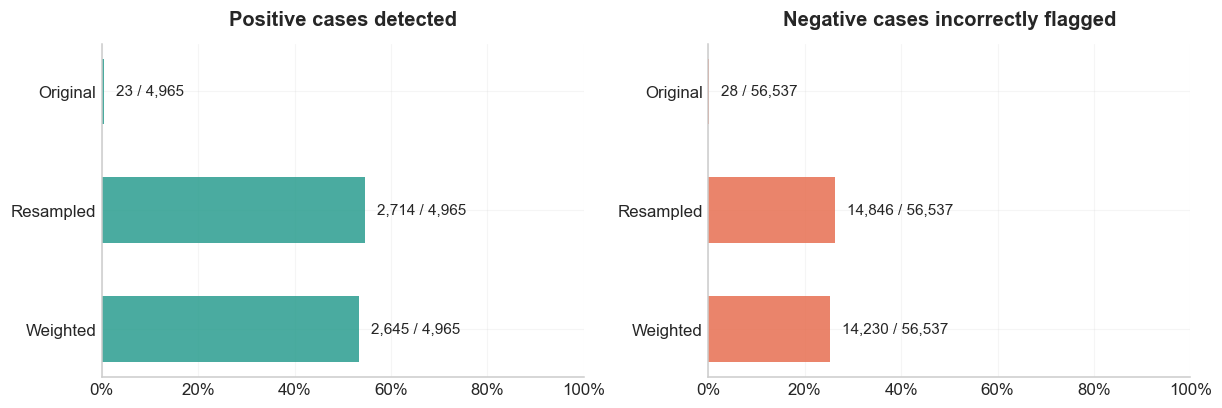

Training,Recall,False-alarm rate,AP
Original,0.5%,0.0%,0.149
Resampled,54.7%,26.3%,0.140
Weighted,53.3%,25.2%,0.139


In [31]:
rng = np.random.default_rng(42)
positive = np.flatnonzero(y_train == 1)
balanced_ids = np.r_[positive, rng.choice(np.flatnonzero(y_train == 0), len(positive), replace=False)]
ordinary = DecisionTreeClassifier(max_depth=3, min_samples_leaf=40, random_state=42).fit(X_train, y_train)
resampled = DecisionTreeClassifier(max_depth=3, min_samples_leaf=40, random_state=42).fit(
    X_train.iloc[balanced_ids], y_train[balanced_ids])
weighted = DecisionTreeClassifier(max_depth=3, min_samples_leaf=40, class_weight='balanced', random_state=42).fit(X_train, y_train)
treatments = {'Original': ordinary, 'Resampled': resampled, 'Weighted': weighted}
rows = []
for name, model in treatments.items():
    p = model.predict_proba(X_val)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_val, p >= .5).ravel()
    rows.append({'Training': name, 'Caught': tp, 'False alarms': fp,
                 'Recall': tp/(tp+fn), 'False-alarm rate': fp/(fp+tn), 'AP': average_precision_score(y_val, p)})
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout='constrained')
for ax, field, color, total in zip(axes, ['Caught', 'False alarms'], [COLORS['soft'], COLORS['val']],
                                  [int(y_val.sum()), int((y_val == 0).sum())]):
    vals = [r[field]/total for r in rows]
    ax.barh(list(treatments), vals, color=color, alpha=.85, height=.55)
    for i, r in enumerate(rows):
        ax.text(vals[i]+.025, i, f'{r[field]:,} / {total:,}', va='center', fontsize=10)
    ax.set(xlim=(0, 1), title='Positive cases detected' if field == 'Caught' else 'Negative cases incorrectly flagged')
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.invert_yaxis()
plt.show()
table([{k:r[k] for k in ['Training', 'Recall', 'False-alarm rate', 'AP']} for r in rows],
      {'Recall':'{:.1%}', 'False-alarm rate':'{:.1%}', 'AP':'{:.3f}'})

Which change would you be willing to accept? Read the two panels together. Catching more positive cases at a fixed threshold need not improve their ranking: average precision (AP) checks a different property. Whether the trade-off is worthwhile depends on the costs and review capacity, which this dataset does not specify.

## 3. What Does Another Split Buy Us?

Turn up the depth while holding the training applications fixed. The curve uses all ten features. The three maps are separate two-feature illustrations, fitted to the same training rows and shown with the same validation points; they are not projections of the ten-feature model.

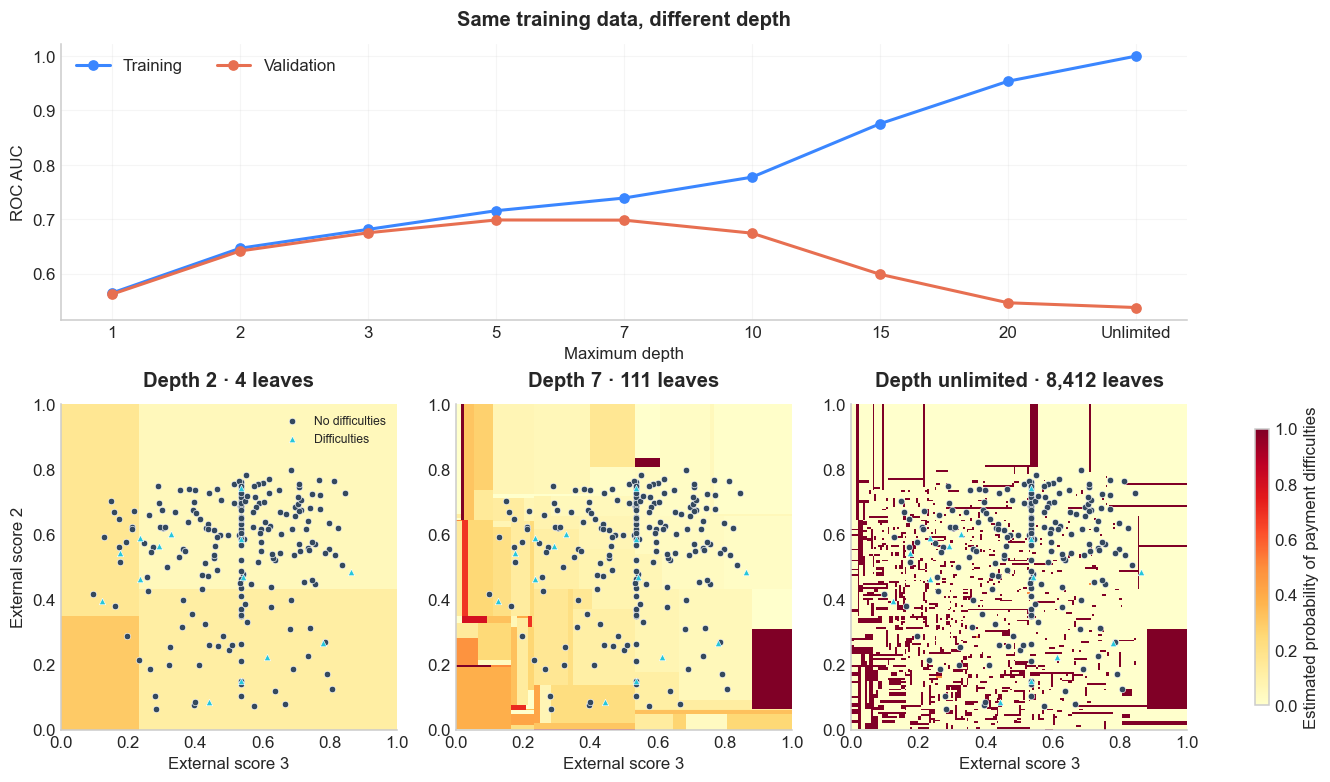

Validation-AUC-selected depth: 5; test applications have not been evaluated.


In [32]:
depths = [1, 2, 3, 5, 7, 10, 15, 20, None]
depth_models, depth_rows = {}, []
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    depth_models[depth] = model
    depth_rows.append({'Depth': depth, 'Leaves': model.get_n_leaves(),
        'Training': roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]),
        'Validation': roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])})
best_depth = depths[int(np.argmax([r['Validation'] for r in depth_rows]))]
best_hard = depth_models[best_depth]
two = ['External score 3', 'External score 2']
xx, yy = np.meshgrid(np.linspace(0, 1, 180), np.linspace(0, 1, 180))
mesh = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=two)
shown = np.random.default_rng(7).choice(len(X_val), 220, replace=False)
fig = plt.figure(figsize=(12, 7), layout='constrained')
gs = fig.add_gridspec(2, 3, height_ratios=[.85, 1])
ax = fig.add_subplot(gs[0, :])
for split in ['Training', 'Validation']:
    ax.plot(range(len(depths)), [r[split] for r in depth_rows], 'o-', lw=2,
            color=COLORS['train' if split == 'Training' else 'val'], label=split)
ax.set(xticks=range(len(depths)), xticklabels=[str(d) if d else 'Unlimited' for d in depths],
       ylabel='ROC AUC', xlabel='Maximum depth', title='Same training data, different depth')
ax.legend(ncol=2)
maps = []
for j, depth in enumerate([2, 7, None]):
    ax = fig.add_subplot(gs[1, j]); maps.append(ax)
    model = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train[two], y_train)
    p = model.predict_proba(mesh)[:, 1].reshape(xx.shape)
    im = ax.pcolormesh(xx, yy, p, vmin=0, vmax=1, cmap=RISK_CMAP, shading='auto', rasterized=True)
    for cls, marker, color in [(0, 'o', '#34495E'), (1, '^', '#26C6DA')]:
        ids = shown[y_val[shown] == cls]
        ax.scatter(*X_val.iloc[ids][two].to_numpy().T, s=18, marker=marker, color=color,
                   edgecolor='white', linewidth=.4, label='No difficulties' if cls == 0 else 'Difficulties')
    ax.set(xlabel=two[0], ylabel=two[1] if j == 0 else '', xlim=(0, 1), ylim=(0, 1),
           title=f'Depth {depth if depth else "unlimited"} · {model.get_n_leaves():,} leaves')
maps[0].legend(fontsize=8, loc='upper right')
fig.colorbar(im, ax=maps, label='Estimated probability of payment difficulties', shrink=.85)
plt.show()
print(f'Validation-AUC-selected depth: {best_depth}; test applications have not been evaluated.')

Where would you stop adding splits? A more intricate map is not automatically a better model. Use the observed validation curve rather than assuming every dataset must reproduce a particular textbook shape.

## 4. Same Observations, Simpler Coordinates

This is a deliberately controlled example: class 1 means $x_2>x_1$. The data have no label noise. First inspect the left panel, then pause: **could one new feature make this easier?** Reveal the right panel after discussing it.

In [39]:
toy_rng = np.random.default_rng(12)
toy_X = toy_rng.uniform(-1, 1, (240, 2))
toy_y = (toy_X[:, 1] > toy_X[:, 0]).astype(int)
toy_tree = DecisionTreeClassifier(max_depth=4, random_state=42).fit(toy_X, toy_y)
u, v = np.meshgrid(np.linspace(-1, 1, 220), np.linspace(-1, 1, 220))
toy_z = toy_tree.predict(np.c_[u.ravel(), v.ravel()]).reshape(u.shape)

def coordinate_story(reveal=False):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout='constrained')
    axes[0].contourf(u, v, toy_z, levels=[-.5, .5, 1.5], colors=['#DDEBFF', '#EBDDF8'], alpha=.8)
    for cls, color in [(0, COLORS['train']), (1, COLORS['positive'])]:
        mask = toy_y == cls
        axes[0].scatter(*toy_X[mask].T, s=22, c=color, edgecolor='white', linewidth=.4, label=f'Class {cls}')
    axes[0].plot([-1, 1], [-1, 1], '--', color=COLORS['ink'], lw=1.5, label='Known rule')
    axes[0].set(xlabel='$x_1$', ylabel='$x_2$', xlim=(-1, 1), ylim=(-1, 1),
                title=f'Original coordinates · {toy_tree.get_n_leaves()} learned leaves', aspect='equal')
    axes[0].legend(fontsize=9, loc='upper left')
    if reveal:
        z = toy_X[:, 1] - toy_X[:, 0]
        for cls, color in [(0, COLORS['train']), (1, COLORS['positive'])]:
            mask = toy_y == cls
            axes[1].scatter(z[mask], np.zeros(mask.sum()), s=35, c=color, alpha=.55)
        axes[1].axvline(0, color=COLORS['ink'], lw=2)
        axes[1].text(-1, .4, 'Class 0', ha='center', color=COLORS['train'])
        axes[1].text(1, .4, 'Class 1', ha='center', color=COLORS['positive'])
        axes[1].set(xlim=(-2, 2), ylim=(-.6, .7), yticks=[], xlabel='$z=x_2-x_1$',
                    title='Same points · one exact rule: z > 0')
        axes[1].grid(False)
    else:
        axes[1].axis('off')
        axes[1].text(.5, .55, 'Can one new feature\nreplace the staircase?',
                     transform=axes[1].transAxes, ha='center', va='center', fontsize=19, color=COLORS['ink'])
        axes[1].text(.5, .26, 'Discuss first; reveal below.', transform=axes[1].transAxes, ha='center', color=COLORS['muted'])
    plt.show()

explore(coordinate_story, reveal=widgets.Checkbox(value=False, description='Reveal coordinates'))

interactive(children=(Checkbox(value=False, description='Reveal coordinates'), Output()), _dom_classes=('widge…

Button(description='Explore this figure', icon='sliders', layout=Layout(width='190px'), style=ButtonStyle())

The representation changed, not the observations. A linear combination of inputs can turn a diagonal rule into one threshold. This motivates an **oblique split** that learns the combination. Whether a split is oblique and whether its routing is soft are separate choices.

## 5. Why Replace the Hard Switch?

Let $s=\mathbf{w}^{\mathsf T}\mathbf{x}+b$. A hard gate asks whether $s>0$; a soft gate assigns right-branch weight $\sigma(s/T)$. This is a **routing weight**, not the probability of payment difficulties. Hard routing has zero derivative away from its threshold and an undefined derivative at it. Soft routing permits backpropagation, although saturated gates can still have very small gradients.

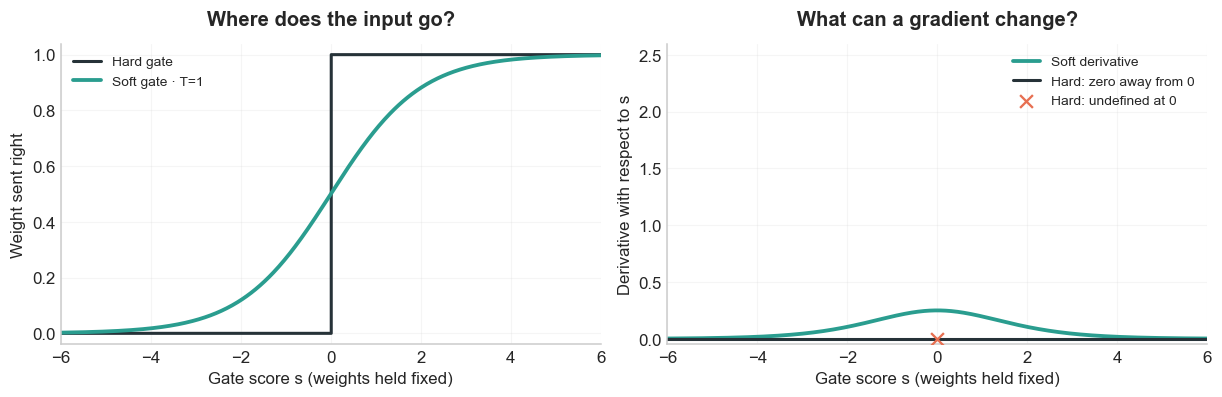

Button(description='Explore this figure', icon='sliders', layout=Layout(width='190px'), style=ButtonStyle())

In [34]:
def gate_story(temperature=1.):
    s = np.linspace(-6, 6, 600)
    p = 1/(1+np.exp(-s/temperature))
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), layout='constrained')
    axes[0].step(s, (s > 0).astype(float), where='post', color=COLORS['ink'], label='Hard gate', lw=2)
    axes[0].plot(s, p, color=COLORS['soft'], label=f'Soft gate · T={temperature:g}', lw=2.5)
    axes[0].set(ylabel='Weight sent right', ylim=(-.04, 1.04), title='Where does the input go?')
    axes[1].plot(s, p*(1-p)/temperature, color=COLORS['soft'], lw=2.5, label='Soft derivative')
    axes[1].plot(s, np.zeros_like(s), color=COLORS['ink'], lw=2, label='Hard: zero away from 0')
    axes[1].scatter([0], [0], marker='x', color=COLORS['val'], s=70, zorder=5, label='Hard: undefined at 0')
    axes[1].set(ylabel='Derivative with respect to s', ylim=(-.05, 2.6), title='What can a gradient change?')
    for ax in axes:
        ax.set(xlabel='Gate score s (weights held fixed)', xlim=(-6, 6)); ax.legend(fontsize=9)
    plt.show()

explore(gate_story, temperature=widgets.FloatLogSlider(value=1, base=10, min=-1, max=.7, step=.1,
                                                       description='Temperature', continuous_update=False))

## 6. One Application, Several Contributions

A soft tree sends weight along several paths. Path weights multiply along branches and sum to one across leaves. Each leaf has its own learned class probability. The final prediction is

$$P(y=1\mid x)=\sum_\ell P(\ell\mid x)\,P(y=1\mid\ell).$$

We fit a depth-two soft tree so every branch remains visible. Unlike the earlier weighting experiment, both this model and the final hard-tree baselines use ordinary, unweighted objectives. Training uses only the 60,000 training rows. We try three fixed seeds, restore each run's best validation checkpoint, and select the lowest validation log loss. The test set is still untouched.

In [40]:
class SoftTree(nn.Module):
    """Three learned oblique gates, four leaves; temperature fixed during fitting."""
    def __init__(self, n_features):
        super().__init__()
        self.gates = nn.Linear(n_features, 3)
        self.leaves = nn.Parameter(torch.randn(4, 2)*.1)

    def forward(self, x, temperature=1., hard=False):
        score = self.gates(x)
        g = (score > 0).float() if hard else torch.sigmoid(score/temperature)
        a, b, c = g.unbind(1)
        paths = torch.stack([(1-a)*(1-b), (1-a)*b, a*(1-c), a*c], dim=1)
        output = paths @ self.leaves.softmax(dim=1)
        return output, paths, g

def fit_soft(seed, epochs=60, patience=8):
    torch.manual_seed(seed)
    model = SoftTree(X_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=.015, weight_decay=.0001)
    xt, yt = torch.from_numpy(train_scaled), torch.tensor(y_train, dtype=torch.long)
    xv, yv = torch.from_numpy(val_scaled), torch.tensor(y_val, dtype=torch.long)
    best_loss, best_epoch, best_state, trace = np.inf, 0, None, []
    for epoch in range(epochs):
        model.train()
        for ids in torch.randperm(len(xt)).split(2048):
            p, _, _ = model(xt[ids])
            loss = nn.functional.nll_loss(p.clamp_min(1e-7).log(), yt[ids])
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        model.eval()
        with torch.no_grad():
            p, _, _ = model(xv)
            val_loss = nn.functional.nll_loss(p.clamp_min(1e-7).log(), yv).item()
        trace.append(val_loss)
        if val_loss < best_loss:
            best_loss, best_epoch, best_state = val_loss, epoch, copy.deepcopy(model.state_dict())
        if epoch-best_epoch >= patience:
            break
    model.load_state_dict(best_state)
    model.eval()
    return model, {'Seed': seed, 'Best epoch': best_epoch+1, 'Epochs run': len(trace), 'Validation log loss': best_loss}

soft_runs = [fit_soft(seed) for seed in (42, 43, 44)]
chosen = min(range(len(soft_runs)), key=lambda i: soft_runs[i][1]['Validation log loss'])
soft_model = soft_runs[chosen][0]
table([run[1] for run in soft_runs], {'Validation log loss':'{:.4f}'})
print(f'Selected seed: {soft_runs[chosen][1]["Seed"]}. No test-set selection.')

Seed,Best epoch,Epochs run,Validation log loss
42,51,59,0.2542
43,58,60,0.2543
44,55,60,0.2543


Selected seed: 42. No test-set selection.


In [41]:
def routing_story(application=44, temperature=1., hard=False):
    with torch.no_grad():
        p, paths, gates = soft_model(torch.from_numpy(val_scaled[[application]]), temperature, hard)
        leaf_risk = soft_model.leaves.softmax(1)[:, 1].numpy()
    paths, gates = paths[0].numpy(), gates[0].numpy()
    mass = np.r_[1., 1-gates[0], gates[0], paths]
    positions = [(0.5, .92), (.25, .64), (.75, .64), (.125, .30), (.375, .30), (.625, .30), (.875, .30)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios':[1.65, 1]}, layout='constrained')
    ax = axes[0]
    for node in range(1, 7):
        parent = (node-1)//2
        x0,y0 = positions[parent]; x1,y1 = positions[node]
        ax.plot([x0,x1], [y0,y1], color=COLORS['soft'], lw=.7+9*mass[node], alpha=.25+.7*mass[node], zorder=1)
        ax.text((x0+x1)/2, (y0+y1)/2, f'{mass[node]:.1%}', ha='center', fontsize=10,
                bbox={'facecolor':'white','edgecolor':'none','pad':1.5}, zorder=2)
    for node,(x0,y0) in enumerate(positions):
        label = f'Gate {node+1}\nright = {gates[node]:.1%}' if node < 3 else f'Leaf {node-2}\nrisk = {leaf_risk[node-3]:.1%}'
        ax.text(x0,y0,label,ha='center',va='center',fontsize=11,
                bbox={'boxstyle':'round,pad=.5','fc':'#E5F3EF' if node<3 else '#F2F4F8','ec':'#AAB8B4'}, zorder=3)
    ax.text(.5,.08,'Edge labels: fraction of the original input weight\nEach gate uses a learned mixture of the ten features.',
            ha='center',va='center',fontsize=10,color=COLORS['ink'])
    ax.set(xlim=(0,1),ylim=(0,1.07),title=f'Application {application} · {"hard" if hard else "soft"} routing')
    ax.axis('off')
    contributions = paths*leaf_risk
    axes[1].barh(range(4), contributions, color=COLORS['soft'], height=.55)
    for i in range(4):
        axes[1].text(contributions[i]+.015,i,f'{paths[i]:.1%} × {leaf_risk[i]:.1%} = {contributions[i]:.1%}',va='center',fontsize=10)
    axes[1].set(yticks=range(4),yticklabels=[f'Leaf {i+1}' for i in range(4)],xlim=(0,1),
                xlabel='Contribution to positive-class probability',title=f'Sum of contributions = {p[0,1].item():.1%}')
    axes[1].xaxis.set_major_formatter(PercentFormatter(1)); axes[1].invert_yaxis()
    plt.show()

explore(routing_story,
        application=widgets.IntSlider(value=44,min=0,max=99,description='Application',continuous_update=False),
        temperature=widgets.FloatLogSlider(value=1,base=10,min=-1,max=.7,step=.1,description='Temperature',continuous_update=False),
        hard=widgets.Checkbox(value=False,description='Hard routing, same gates'))

interactive(children=(IntSlider(value=44, continuous_update=False, description='Application', max=99), FloatLo…

Button(description='Explore this figure', icon='sliders', layout=Layout(width='190px'), style=ButtonStyle())

Follow the weights all the way to the sum. The temperature control changes routing **without retraining**; it is not a search for the best temperature. The hard-routing switch holds the learned oblique gates and leaf probabilities fixed, isolating routing rather than comparing two different fitted architectures.

Application 44 is the same validation record highlighted earlier, selected from the first 100 records to make several paths visible. This illustration choice does not affect training, model selection, or the reported test metrics.

Many paths need not mean an uncertain prediction: if all four leaves predict 80%, any mixture still predicts 80%. Conversely, one hard path can end at a 50/50 leaf. Routing concentration, class probability, and calibration are different things.

## 7. One Final Check on Unseen Applications

Freeze the choices now. We compare the opening four-leaf hard tree, the validation-selected deeper hard tree, and the validation-selected four-leaf soft tree. Equal depth does not imply equal capacity: soft gates combine all ten features. The deeper hard tree is a stronger reference than the opening example alone. All predictions below use the original test population; none uses a 50/50 test subset.

Model,ROC AUC,AP,Log loss,Brier
Hard · 4 leaves,0.651,0.138,0.266,0.072
Hard · selected depth 5,0.703,0.174,0.266,0.071
Soft · 4 leaves,0.731,0.216,0.254,0.069


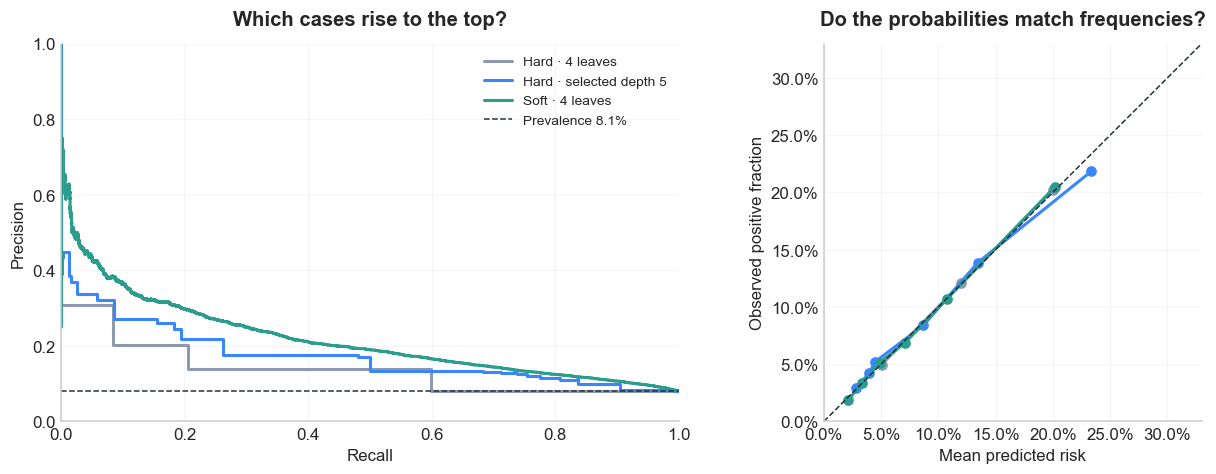

Test population: 61,503 applications, 4,965 positive cases.


In [37]:
X_test = pd.DataFrame(imputer.transform(X.iloc[test_ids]), columns=X.columns)
y_test = y[test_ids]
with torch.no_grad():
    soft_test = soft_model(torch.tensor(scaler.transform(X_test), dtype=torch.float32))[0][:, 1].numpy()
test_predictions = {'Hard · 4 leaves': shallow.predict_proba(X_test)[:, 1],
                    f'Hard · selected depth {best_depth}': best_hard.predict_proba(X_test)[:, 1],
                    'Soft · 4 leaves': soft_test}
score_rows = [{'Model': name, 'ROC AUC': roc_auc_score(y_test,p),
               'AP': average_precision_score(y_test,p), 'Log loss': log_loss(y_test,p),
               'Brier': brier_score_loss(y_test,p)} for name,p in test_predictions.items()]
table(score_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')
model_colors = [COLORS['muted'], COLORS['train'], COLORS['soft']]
for (name,p),color in zip(test_predictions.items(),model_colors):
    precision, recall, _ = precision_recall_curve(y_test,p)
    axes[0].step(recall,precision,where='post',color=color,lw=2,label=name)
    observed, predicted = calibration_curve(y_test,p,n_bins=6,strategy='quantile')
    axes[1].plot(predicted,observed,'o-',color=color,lw=2,label=name)
axes[0].axhline(y_test.mean(),color=COLORS['ink'],ls='--',lw=1,label=f'Prevalence {y_test.mean():.1%}')
axes[0].set(xlabel='Recall',ylabel='Precision',xlim=(0,1),ylim=(0,1),title='Which cases rise to the top?')
axes[0].legend(fontsize=9)
axes[1].plot([0,1],[0,1],'--',color=COLORS['ink'],lw=1)
cal_limit = min(1., max(.3, max(max(calibration_curve(y_test,p,n_bins=6,strategy='quantile')[k])
                             for p in test_predictions.values() for k in [0,1]))*1.1)
axes[1].set(xlabel='Mean predicted risk',ylabel='Observed positive fraction',xlim=(0,cal_limit),ylim=(0,cal_limit),
            title='Do the probabilities match frequencies?',aspect='equal')
axes[1].xaxis.set_major_formatter(PercentFormatter(1)); axes[1].yaxis.set_major_formatter(PercentFormatter(1))
plt.show()
print(f'Test population: {len(y_test):,} applications, {int(y_test.sum()):,} positive cases.')

**Advanced discussion:** ranking and probability quality answer different questions. The calibration panel groups predictions into up to six quantile bins; tied tree scores can produce fewer bins. These are descriptive averages, not confidence intervals. Use log loss and Brier score alongside the plot. This single dataset and split do not establish that soft trees are generally better calibrated or more accurate.

## Wrap-up

A decision tree turns a prediction into a sequence of questions, but following one path does not make the answer certain. More splits can capture useful structure or fit details that do not generalize; better features can sometimes replace an elaborate staircase with one question. Soft trees let several leaves contribute to a prediction and make routing trainable through gradients. That changes how the model learns, not what we should demand from its evaluation: separate validation from testing, compare like with like, and check both the ordering of cases and the quality of their probabilities.

### Sources

[Home Credit data and access terms](https://www.kaggle.com/competitions/home-credit-default-risk/data) · [scikit-learn decision trees](https://scikit-learn.org/stable/modules/tree.html) · [Frosst & Hinton: Distilling a Neural Network Into a Soft Decision Tree (2017)](https://arxiv.org/abs/1711.09784) · [Kontschieder et al.: Deep Neural Decision Forests (2015)](https://openaccess.thecvf.com/content_iccv_2015/html/Kontschieder_Deep_Neural_Decision_ICCV_2015_paper.html)

The soft tree here is a small supervised teaching implementation, not a reproduction of either paper's full method. The code uses PyTorch, scikit-learn, NumPy, pandas, Matplotlib, and ipywidgets.